# DCFC Data Scientist Task - Sam Forrest
## Tactical Investigation

This analysis investigates how teams can create shooting opportunities more effectively.

Using StatsBomb 360 data from the 2023/24 Bundesliga season, we focus on Bayer Leverkusen to identify what differentiates attacking passes that lead to immediate shots from similar passes that do not, with emphasis on the role of spatial context at the moment of delivery.

Understanding these differences can inform both tactical decision-making and player profiling.

Whilst not all shots are of equal quality, shot creation provides a clear and consistent definition of attacking success. This allows for robust and interpretable modelling, where further analysis of shot quality could be considered in future iterations of this model, where more data is available.

### Requirements:

The following packages have been utilised and may need to be installed if they are not default Python packages:
- statsbombpy
- pandas
- numpy
- tqdm
- json
- urllib
- matplotlib
- seaborn
- scikit-learn

In my submission, I will also include a .yml file of the exact Python environment I have used to run this notebook so you can exactly replicate it.

In [1]:
# Core imports
from statsbombpy import sb
import pandas as pd
import numpy as np
from tqdm import tqdm
import json
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

# Verify Python version
print(f"Python: {__import__('sys').version}")

Python: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


## Data Collection and Preparation

Event and 360 freeze-frame data from the 2023/24 Bundesliga season were accessed using statsbombpy.

The dataset includes:
- All on-ball events (passes, shots, carries, etc.)
- Contextual spatial data (player positions at the moment of each event)

In [2]:
# Load Bundesliga 2023/24 matches
matches = sb.matches(competition_id=9, season_id=281)
print(f"Matches: {matches.shape[0]}")

# Grab first match id
match_id = matches['match_id'].iloc[0]
print(f"Test match ID: {match_id}")

Matches: 34
Test match ID: 3895302


##### Due to issues encountered when indexing the 360 frame data via the standard interface, I created a custom load_frames() function to retrieve the raw JSON directly from the StatsBomb Open Data repository. This approach ensures consistent access to the required freeze-frame data and provides greater control over data handling within the analysis.

In [3]:
def load_frames(match_id):
    url = f"https://raw.githubusercontent.com/statsbomb/open-data/master/data/three-sixty/{match_id}.json"
    with urllib.request.urlopen(url) as response:
        raw = json.load(response)
    
    rows = []
    for event in raw:
        event_id = event.get('event_uuid')
        visible_area = event.get('visible_area')
        for player in event.get('freeze_frame', []):
            row = {
                'id': event_id,
                'visible_area': visible_area,
                'teammate': player.get('teammate'),
                'actor': player.get('actor'),
                'keeper': player.get('keeper'),
                'location_x': player['location'][0],
                'location_y': player['location'][1]
            }
            rows.append(row)
    
    return pd.DataFrame(rows)

# Testing it worked
frames = load_frames(match_id)
print(frames.shape)
print(frames.columns.tolist())
display(frames.head())

(56319, 7)
['id', 'visible_area', 'teammate', 'actor', 'keeper', 'location_x', 'location_y']


,id,visible_area,teammate,actor,keeper,location_x,location_y
0,ff56e821-21e9-4cef-ba2a-7eb5eb3769c6,"[16.638549335883955, 80.0, 42.634221931834276,...",True,False,False,33.623682,40.159019
1,ff56e821-21e9-4cef-ba2a-7eb5eb3769c6,"[16.638549335883955, 80.0, 42.634221931834276,...",True,False,False,36.740414,53.639992
2,ff56e821-21e9-4cef-ba2a-7eb5eb3769c6,"[16.638549335883955, 80.0, 42.634221931834276,...",True,False,False,41.681402,24.747151
3,ff56e821-21e9-4cef-ba2a-7eb5eb3769c6,"[16.638549335883955, 80.0, 42.634221931834276,...",True,False,False,45.758525,34.307303
4,ff56e821-21e9-4cef-ba2a-7eb5eb3769c6,"[16.638549335883955, 80.0, 42.634221931834276,...",True,False,False,49.770820,49.754722


In [4]:
# Load events for same match
events = sb.events(match_id=match_id)

# Join frames to events on id
events_with_360 = events[events['id'].isin(frames['id'])]
print(f"Total events: {len(events)}")
print(f"Events with 360 data: {len(events_with_360)}")
print(f"\nEvent types with 360 coverage:")
display(events_with_360['type'].value_counts())

Total events: 4223
Events with 360 data: 3525

Event types with 360 coverage:


type
Ball Receipt*     968
Pass              952
Carry             868
Pressure          384
Ball Recovery      82
Duel               44
Block              35
Shot               25
Dribble            23
Clearance          22
Dispossessed       21
Miscontrol         19
Goal Keeper        17
Foul Committed     16
Interception       15
Foul Won           15
Dribbled Past      11
50/50               4
Offside             2
Error               1
Shield              1
Name: count, dtype: int64

In [5]:
# Get shots with their context
shots = events[events['type'] == 'Shot'].copy()
shot_cols = [c for c in shots.columns if c.startswith('shot_')]
display(shots[shot_cols].notna().sum().sort_values(ascending=False))

shot_body_part       27
shot_end_location    27
shot_type            27
shot_statsbomb_xg    27
shot_technique       27
shot_outcome         27
shot_freeze_frame    26
shot_key_pass_id     18
shot_first_time       9
shot_aerial_won       2
shot_one_on_one       2
dtype: int64

In [6]:
# Also look at what pass tags look like just before shots
# Find the possession chain leading to each shot
shots_sample = shots[['id', 'possession', 'location', 
                       'shot_outcome', 'shot_statsbomb_xg']].head(10)
display(shots_sample)

,id,possession,location,shot_outcome,shot_statsbomb_xg
4093,c577e730-b9f5-44f2-9257-9e7730c23d7b,13,"[100.4, 35.1]",Blocked,0.056644
4094,bbc2c68d-c096-483d-abf4-32c0175a0f55,14,"[114.6, 33.5]",Saved,0.143381
4095,12b5206b-9ed0-4b1e-9ec3-f2028187e09f,22,"[106.2, 55.8]",Blocked,0.038188
4096,b2c3d59d-3bef-4f8a-ad86-26b69940c64e,26,"[113.9, 47.4]",Blocked,0.052781
4097,bb53b537-1685-4019-9e8f-98f3805828eb,33,"[89.2, 42.5]",Blocked,0.021272
4098,0247fb51-7bf7-4be6-82d7-bf63892bdd53,34,"[110.2, 32.6]",Wayward,0.029664
4099,b6b96d19-97e3-4770-996a-f20696123abe,38,"[105.4, 45.1]",Blocked,0.082293
4100,cf7357c9-3bd6-425f-ac34-ef7f11897394,42,"[108.0, 40.0]",Goal,0.783500
4101,93d22a32-8221-4cab-9d68-d68f4b600599,45,"[101.5, 47.5]",Blocked,0.050110
4102,5d2bf27b-dd07-4895-8744-1673b235fcec,46,"[116.3, 46.0]",Saved,0.109917


In [7]:
# Load all 34 matches worth of events

all_events = []
for mid in tqdm(matches['match_id']):
    e = sb.events(match_id=mid)
    all_events.append(e)

events_all = pd.concat(all_events, ignore_index=True)
print(events_all.shape)
print(events_all['type'].value_counts())

100%|██████████████████████████████████████████████████████████████████████████████████| 34/34 [00:22<00:00,  1.51it/s]

(137765, 111)
type
Pass                 39214
Ball Receipt*        38215
Carry                32369
Pressure             11419
Ball Recovery         3222
Duel                  2022
Block                 1434
Clearance             1248
Goal Keeper           1102
Shot                   916
Dribble                913
Miscontrol             903
Dispossessed           759
Foul Committed         758
Interception           738
Foul Won               726
Dribbled Past          519
Substitution           301
50/50                  201
Half Start             136
Half End               136
Tactical Shift         127
Injury Stoppage        106
Starting XI             68
Shield                  49
Referee Ball-Drop       38
Bad Behaviour           34
Player Off              27
Player On               27
Error                   21
Offside                 11
Own Goal For             3
Own Goal Against         3
Name: count, dtype: int64


In [8]:
passes = events_all[events_all['type'] == 'Pass']
print("Passes: "+str(len(passes)))
shots = events_all[events_all['type'] == 'Shot']
print("Shots: "+str(len(shots)))

Passes: 39214
Shots: 916


In [9]:
leverkusen = events_all[events_all['team'] == 'Bayer Leverkusen'].copy()

In [10]:
leverkusen.groupby('possession').size().describe()

count    189.000000
mean     430.899471
std      201.662519
min        2.000000
25%      323.000000
50%      459.000000
75%      561.000000
max      846.000000
dtype: float64

### Events per possession

I thought of limiting actions to assess passes that occurred N events before a shot or chance creation.

- mean = 431 events per possession
- median = 459 events per possession

Given the large number of events within possessions, defining attribution windows based on possession or fixed event counts risks including unrelated actions. Therefore, we focus on the final pass before each shot to ensure clear attribution.

In [11]:
# Checking output
display(leverkusen)

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,pass_straight,shot_open_goal,dribble_no_touch,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_shot_saved_to_post,shot_saved_to_post,clearance_other,goalkeeper_success_out,goalkeeper_success_in_play
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
137760,NaN,Yellow Card,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
137761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
137762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
leverkusen_passes = leverkusen[leverkusen['type'] == 'Pass'].copy()

In [13]:
# Checking output of leverkusen_passes
print(leverkusen_passes.shape)
display(leverkusen_passes[['pass_length', 'pass_angle', 'pass_end_location']].head())

(24244, 111)


,pass_length,pass_angle,pass_end_location
15,26.521688,-2.779292,"[8.5, 33.8]"
16,13.958868,-1.078311,"[15.1, 21.5]"
17,15.800000,0.000000,"[38.1, 19.5]"
18,8.200000,3.141593,"[29.9, 19.5]"
19,21.105923,1.547104,"[48.6, 49.7]"


### Defining target variable

I am confident that the event data has been correctly filtered to include all Leverkusen passes from the 2023/24 season, resulting in 24,244 passes available for analysis.

The target variable is defined as whether a pass is a shot assist.

Shot creation is defined as the final pass immediately preceding a shot, with no intervening actions. As a result, this definition excludes situations where the receiver takes one or more touches before shooting, and therefore captures only direct chance creation.

This definition aligns with the standard used by StatsBomb, ensuring that attribution between action and outcome remains clear and consistent. While this approach may exclude certain realistic scenarios (e.g. a player taking a controlling touch before shooting), it avoids introducing subjective or complex attribution rules, in this first instance.

In future work, it may be valuable to extend this definition to account for short sequences of actions following a pass. However, doing so would increase model complexity and reduce interpretability, and is therefore considered outside the scope for this specific analysis.

In [14]:
leverkusen_passes['is_shot_assist'] = leverkusen_passes['pass_shot_assist'].fillna(False)

In [15]:
# Checking above as a proportion
leverkusen_passes['is_shot_assist'].value_counts(normalize=True)

is_shot_assist
False    0.982882
True     0.017118
Name: proportion, dtype: float64

In [16]:
# Checking raw values
leverkusen_passes['is_shot_assist'].value_counts()

is_shot_assist
False    23829
True       415
Name: count, dtype: int64

##### The observed class imbalance, with approximately 98% of passes not leading to a shot, is consistent with typical match dynamics in football. Given this imbalance, model evaluation will focus on the interpretability of feature effects rather than raw predictive accuracy.

##### At a base rate of 1.71%, this corresponds to 415 passes leading to a shot. While the positive class is relatively small, this remains sufficient for an interpretable modelling approach, provided model complexity is kept low and the number of features is controlled.

## Final Third Passes
To focus on meaningful attacking actions while avoiding subjective filtering based on pass intent, the analysis is restricted to passes occurring in the final third of the pitch.

In [17]:
leverkusen_passes['x'] = leverkusen_passes['location'].apply(lambda x: x[0] if isinstance(x, list) else None)

final_third_passes = leverkusen_passes[leverkusen_passes['x'] >= 80].copy().reset_index()

In [18]:
display(final_third_passes.shape)

(6657, 114)

In [19]:
# Checking distribution of target variables
final_third_passes['is_shot_assist'].value_counts(normalize=True)

is_shot_assist
False    0.94502
True     0.05498
Name: proportion, dtype: float64

In [20]:
# Checking distribution in raw terms
final_third_passes['is_shot_assist'].value_counts()

is_shot_assist
False    6291
True      366
Name: count, dtype: int64

##### By restricting the sample to passes in the final third, the overall sample size is reduced (24,244 passes to 6,657), but the proportion of passes leading to a shot increases, partially addressing the class imbalance observed previously. This comes at the cost of losing approximately 12% of shot-assist passes (415 to 366). However, it removes a large number of build-up and low-risk passes, reducing noise in the dataset. As a result, the analysis focuses on actions that are more likely to contribute to chance creation.

### Creating features
The first feature I will create is how far away the nearest defender is to the player who received the pass, at the moment the pass was played.

In [21]:
# Loading all 360 frame data for the specific matches
all_frames = []

for mid in tqdm(matches['match_id']):
    try:
        f = load_frames(mid)
        all_frames.append(f)
    except Exception as e:
        print(f"Could not load frames for match {mid}: {e}")

frames_all = pd.concat(all_frames, ignore_index=True)

print(frames_all.shape)
frames_all.head()

100%|██████████████████████████████████████████████████████████████████████████████████| 34/34 [00:59<00:00,  1.76s/it]

(1953182, 7)


,id,visible_area,teammate,actor,keeper,location_x,location_y
0,ff56e821-21e9-4cef-ba2a-7eb5eb3769c6,"[16.638549335883955, 80.0, 42.634221931834276,...",True,False,False,33.623682,40.159019
1,ff56e821-21e9-4cef-ba2a-7eb5eb3769c6,"[16.638549335883955, 80.0, 42.634221931834276,...",True,False,False,36.740414,53.639992
2,ff56e821-21e9-4cef-ba2a-7eb5eb3769c6,"[16.638549335883955, 80.0, 42.634221931834276,...",True,False,False,41.681402,24.747151
3,ff56e821-21e9-4cef-ba2a-7eb5eb3769c6,"[16.638549335883955, 80.0, 42.634221931834276,...",True,False,False,45.758525,34.307303
4,ff56e821-21e9-4cef-ba2a-7eb5eb3769c6,"[16.638549335883955, 80.0, 42.634221931834276,...",True,False,False,49.770820,49.754722


In [22]:
# Checking the coverage of 360 data for the final third passes
passes_with_360 = final_third_passes[final_third_passes['id'].isin(frames_all['id'])].copy()

print('final_third_passes shape: ' + str(final_third_passes.shape))
print('passes_with_360 shape: '+ str(passes_with_360.shape))
print('% of final_third_passes with 360 data: ' + str(len(passes_with_360) / len(final_third_passes)))
print('-------------------------')
print('final_third_passes posistive signal count: '+ str(final_third_passes['is_shot_assist'].value_counts()))
print('passes_with_360 positive signal count: '+ str(passes_with_360['is_shot_assist'].value_counts()))

final_third_passes shape: (6657, 114)
passes_with_360 shape: (5672, 114)
% of final_third_passes with 360 data: 0.8520354514045366
-------------------------
final_third_passes posistive signal count: is_shot_assist
False    6291
True      366
Name: count, dtype: int64
passes_with_360 positive signal count: is_shot_assist
False    5344
True      328
Name: count, dtype: int64


#### Analysis
Approximately 85% of final-third passes have associated 360 frame data. The majority of shot-assist passes are also retained, and the proportion of passes leading to a shot remains consistent, suggesting no obvious bias is introduced by restricting the sample. The potential value of incorporating spatial context from the 360 data should outweigh the slight loss in sample size.

In [23]:
# Merging passes_with_360 to the frame information
passes_frames = passes_with_360.merge(frames_all, on='id', how='left')

In [24]:
# Checking dataframe
print(passes_frames.shape)
passes_frames[['id', 'teammate', 'location_x', 'location_y']].head()

(99189, 120)


,id,teammate,location_x,location_y
0,7a9e0311-6936-4f6d-aa56-90c0e6ff7b58,False,70.792475,45.835929
1,7a9e0311-6936-4f6d-aa56-90c0e6ff7b58,True,71.332075,37.208986
2,7a9e0311-6936-4f6d-aa56-90c0e6ff7b58,False,72.099102,58.831688
3,7a9e0311-6936-4f6d-aa56-90c0e6ff7b58,True,74.342263,74.495378
4,7a9e0311-6936-4f6d-aa56-90c0e6ff7b58,True,79.824265,57.252766


In [25]:
# Checking each pass has a maximum of 22 players 'visible' and we have the correct number of passses
passes_frames.groupby('id').size().describe()

count    5672.000000
mean       17.487482
std         2.576740
min         4.000000
25%        16.000000
50%        18.000000
75%        19.000000
max        22.000000
dtype: float64

In [26]:
(passes_frames.groupby('id').size() < 10).mean()

np.float64(0.008638928067700988)

#### Analysis
The minimum number of players visible in a frame is 4, suggesting that some events have limited spatial coverage. To assess the extent of this, the proportion of frames with fewer than 10 visible players was calculated. This shows that less than 1% of frames are sparse, indicating that incomplete frames are rare and unlikely to impact the analysis too much. Given this, no filtering was applied.

In [27]:
# Keeping only opposition players
defenders = passes_frames[passes_frames['teammate'] == False].copy()

In [28]:
# Checking output
print(defenders.shape)
# Just over half the total rows of the passes_frames dataframe which would be around what we should expect

(54829, 120)


In [29]:
# Extracting pass end coordinates
defenders['end_x'] = defenders['pass_end_location'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) >= 2 else None
)
defenders['end_y'] = defenders['pass_end_location'].apply(
    lambda x: x[1] if isinstance(x, list) and len(x) >= 2 else None
)

In [30]:
# Calculating the distance of each defender from the pass receiver
defenders['distance_to_receiver'] = np.sqrt(
    (defenders['location_x'] - defenders['end_x'])**2 +
    (defenders['location_y'] - defenders['end_y'])**2
)

In [31]:
# Checking output looks right
defenders[['location_x', 'location_y', 'end_x', 'end_y', 'distance_to_receiver']].head()

,location_x,location_y,end_x,end_y,distance_to_receiver
0,70.792475,45.835929,102.7,63.5,36.470667
2,72.099102,58.831688,102.7,63.5,30.954936
6,84.699939,44.595511,102.7,63.5,26.103293
7,88.854053,74.468260,102.7,63.5,17.663889
9,90.335983,60.827150,102.7,63.5,12.649626


In [32]:
# Grouping passes back together by minimum distance
nearest_defender = (
    defenders.groupby('id', as_index=False)['distance_to_receiver']
    .min()
    .rename(columns={'distance_to_receiver': 'nearest_defender_distance'})
)

In [33]:
# Checking output has correct number of rows
print(nearest_defender.shape)
nearest_defender.head()

(5672, 2)


,id,nearest_defender_distance
0,000367bb-60f0-4061-bf44-717ace7c0fd7,10.952520
1,0013f6c5-7ceb-4e94-b045-913e48f1fb13,3.054626
2,00193dd3-e594-4e1e-bf50-6a4087f2beb5,6.796627
3,0022baf5-a85e-409c-9939-9314319a9150,10.024045
4,002b3c5f-75ee-46c8-a45c-6427e5e56e44,9.872021


In [34]:
# Merging back into pass dataset
passes_with_360 = passes_with_360.merge(nearest_defender, on='id', how='left')

In [35]:
# Sanity checking output
passes_with_360['nearest_defender_distance'].describe()

count    5672.000000
mean        8.435021
std         5.533141
min         0.063422
25%         4.229634
50%         7.484019
75%        11.605693
max        44.468250
Name: nearest_defender_distance, dtype: float64

In [36]:
# Checking missing values
passes_with_360['nearest_defender_distance'].isna().mean()

np.float64(0.0)

In [37]:
# Checking mean/median values for positive signal passes
print('Mean')
print(passes_with_360.groupby('is_shot_assist')['nearest_defender_distance'].mean())
print('------------')
print('Median')
print(passes_with_360.groupby('is_shot_assist')['nearest_defender_distance'].median())

Mean
is_shot_assist
False    8.534925
True     6.807322
Name: nearest_defender_distance, dtype: float64
------------
Median
is_shot_assist
False    7.627936
True     5.826046
Name: nearest_defender_distance, dtype: float64


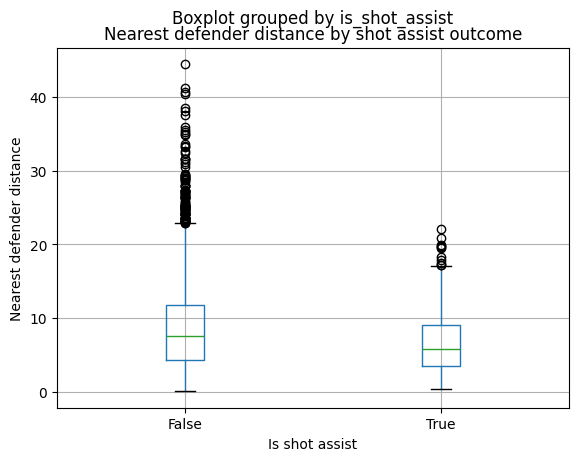

In [38]:
passes_with_360.boxplot(column='nearest_defender_distance', by='is_shot_assist')
plt.title('Nearest defender distance by shot assist outcome')
plt.xlabel('Is shot assist')
plt.ylabel('Nearest defender distance')
plt.show()

#### Data Analysis Insight
Interestingly, it appears that passes leading to shots tend to occur in areas with closer defensive proximity. This likely reflects a positional effect that passes leading to shots tend to end in central and advanced areas, which are also the areas where the defenders are most concentrated.

The next feature I want to create off the back of this is defender density - how many defenders are within 5 StatsBomb units (4-5 metres) of the receiver of the pass when the pass was played. I selected 5 units as anything smaller is when a player would be almost touch-tight which would be too close, and a larger radius would likely take into account general congestion which would bring too much noise.

In [39]:
# Create binary flag for defenders within 5m
radius = 5

defenders['within_5m'] = defenders['distance_to_receiver'] <= radius

In [40]:
# Count defenders inside the radius for each pass
defender_density = (
    defenders.groupby('id', as_index=False)['within_5m']
    .sum()
    .rename(columns={'within_5m': 'defenders_within_5m'})
)

In [41]:
# Merge back
passes_with_360 = passes_with_360.merge(defender_density, on='id', how='left')

In [42]:
# Check output
passes_with_360['defenders_within_5m'].describe()

count    5672.000000
mean        0.495416
std         0.944023
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         9.000000
Name: defenders_within_5m, dtype: float64

In [43]:
# Missing values
passes_with_360['defenders_within_5m'].isna().mean()

np.float64(0.0)

In [44]:
print('Mean')
print(passes_with_360.groupby('is_shot_assist')['defenders_within_5m'].mean())
print('------------')
print('Median')
print(passes_with_360.groupby('is_shot_assist')['defenders_within_5m'].median())

Mean
is_shot_assist
False    0.482410
True     0.707317
Name: defenders_within_5m, dtype: float64
------------
Median
is_shot_assist
False    0.0
True     0.0
Name: defenders_within_5m, dtype: float64


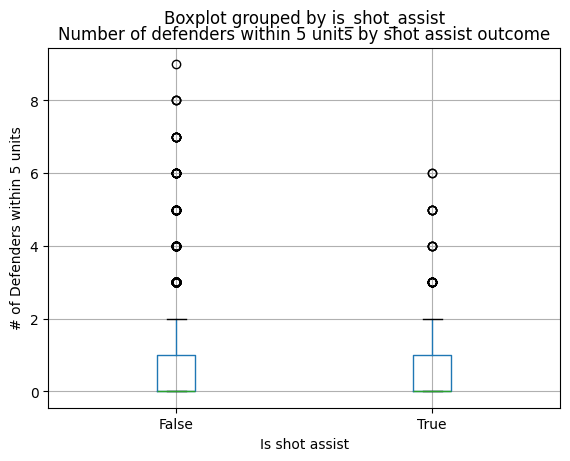

In [45]:
passes_with_360.boxplot(column='defenders_within_5m', by='is_shot_assist')
plt.title('Number of defenders within 5 units by shot assist outcome')
plt.xlabel('Is shot assist')
plt.ylabel('# of Defenders within 5 units')
plt.show()

#### Data Analysis Insight
What is shown above is fairly consistent with what we saw with the previously created feature. Above, shot assists had a closer nearest defender and this feature shows that there are, on average, more defenders close by. This suggests that passes leading to shots in this sample tend to occur in more congested areas of the pitch, rather than in open space. This is potentially due to the same positional effect mentioned for the above feature.

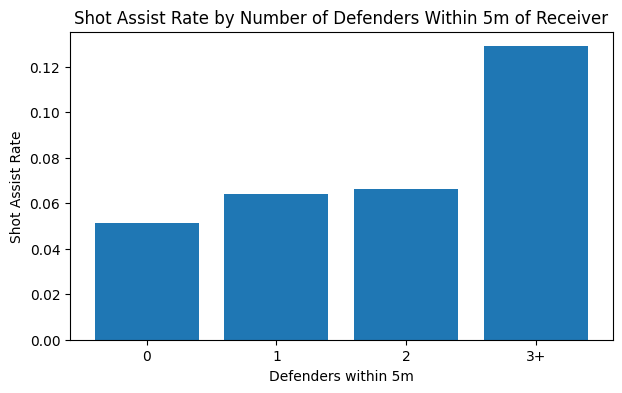

In [46]:
# Shot assist rate by number of defenders within 5m
density_chart = (
    passes_with_360
    .assign(defenders_bucket=passes_with_360['defenders_within_5m'].clip(upper=3)
            .map({0: '0', 1: '1', 2: '2', 3: '3+'}))
    .groupby('defenders_bucket')['is_shot_assist']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.bar(density_chart['defenders_bucket'], density_chart['is_shot_assist'])
plt.title('Shot Assist Rate by Number of Defenders Within 5m of Receiver')
plt.xlabel('Defenders within 5m')
plt.ylabel('Shot Assist Rate')
plt.show()

In [47]:
# Checking density of plot
density_chart = (
    passes_with_360
    .assign(defenders_bucket=passes_with_360['defenders_within_5m'].clip(upper=3)
            .map({0: '0', 1: '1', 2: '2', 3: '3+'}))
    .groupby('defenders_bucket')['is_shot_assist']
    .agg(['mean', 'count'])
    .reset_index()
)

print(density_chart)

  defenders_bucket      mean  count
0                0  0.051125   3912
1                1  0.064286   1120
2                2  0.066194    423
3               3+  0.129032    217


### Analysis
Shot assist rate increases consistently with the number of defenders near the receiver. The trend across 0, 1, and 2 nearby defenders is based on large sample sizes and is fairly stable, suggesting that passes into more contested areas are more likely to lead to shots, likely reflecting that these areas tend to be more central and advanced.

The jump to 13% for passes with 3+ nearby defenders is more pronounced, though this bucket contains fewer observations (n=217) and the elevated rate is likely partly explained by those passes already being in high-value locations such as in or around the box, rather than defender density itself being the driver.

## Features included in the dataset
#### The following are features that already exist in the event data that I want to utilise as features:
- pass_length - the distance the pass travelled
- pass_angle - the direction of the pass
- start_x - how high up the pitch the pass started from
- start_y - how wide, or central, the pass started from
- end_x - how high up the pitch the pass ended
- end_y - how wide, or central, the pass ended
- under_pressure - binary for whether the passer is "under pressure" (StatsBomb defined) when passing
- high_pass - binary for if StatsBomb labelled the pass as "High" or not (0 in this instance is a ground or low pass)
-is_cross - whether the pass was listed as a cross or not by StatsBomb

##### Couple the above with the engineered features from the 360 data:
- nearest_defender_distance - how close the nearest defender was to the pass receiver when the pass was played
- defenders_within_5m - the number of defenders within 5 StatsBomb units (around 5 metres) of the pass receiver when the pass was played

##### Together, these features capture three key aspects of passing:
- Execution: how the pass is played (length and direction)
- Location: where the pass starts and ends on the pitch
- Context: the defensive pressure surrounding the passer and receiver

I wanted to try and implement a feature for whether the pass was into feet or onto a runner but there is no existing information for that in the StatsBomb event data, and the best way I could think to proxy it would be to combine pass_length and nearest_defender_distance from the 360 data. This would've assumed that longer passes with a further away nearest defender were balls to run onto and otherwise were passes into feet. This felt a bit too hacky and likely not worth including for this specific ask, but would potentially be interesting to explore further down the line.

Below, I will perform some basic checks to make sure the data is approximately what would be expected.

In [48]:
passes_with_360['pass_length'].describe()

count    5672.000000
mean       15.446372
std         9.696708
min         0.000000
25%         8.940358
50%        13.040130
75%        19.061478
max        80.103060
Name: pass_length, dtype: float64

In [49]:
passes_with_360['pass_angle'].describe()

count    5672.000000
mean       -0.065803
std         1.800563
min        -3.133900
25%        -1.635679
50%        -0.138344
75%         1.547633
max         3.141593
Name: pass_angle, dtype: float64

In [50]:
passes_with_360['start_x'] = passes_with_360['location'].apply(lambda x: x[0])
passes_with_360['start_x'].describe()

count    5672.000000
mean       94.425793
std        10.607682
min        80.000000
25%        85.400000
50%        91.900000
75%       100.825000
max       120.000000
Name: start_x, dtype: float64

In [51]:
passes_with_360['start_y'] = passes_with_360['location'].apply(lambda x: x[1])
passes_with_360['start_y'].describe()

count    5672.000000
mean       41.357616
std        24.502310
min         0.100000
25%        18.900000
50%        44.000000
75%        63.000000
max        80.000000
Name: start_y, dtype: float64

In [52]:
passes_with_360['end_x'] = passes_with_360['pass_end_location'].apply(lambda x: x[0] if isinstance(x, list) else None)
passes_with_360['end_x'].describe()

count    5672.000000
mean       94.813452
std        12.977494
min        35.400000
25%        85.100000
50%        95.000000
75%       105.200000
max       120.000000
Name: end_x, dtype: float64

In [53]:
passes_with_360['end_y'] = passes_with_360['pass_end_location'].apply(lambda x: x[1] if isinstance(x, list) else None)
passes_with_360['end_y'].describe()

count    5672.000000
mean       40.413240
std        21.807484
min         0.100000
25%        21.900000
50%        40.900000
75%        58.400000
max        80.000000
Name: end_y, dtype: float64

In [54]:
passes_with_360['under_pressure'] = passes_with_360['under_pressure'].fillna(False).astype(int)
passes_with_360['under_pressure'].describe()

count    5672.000000
mean        0.137165
std         0.344052
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: under_pressure, dtype: float64

In [55]:
passes_with_360['is_high_pass'] = (passes_with_360['pass_height'] == 'High Pass').astype(int)
passes_with_360['is_high_pass'].describe()

count    5672.000000
mean        0.116714
std         0.321107
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: is_high_pass, dtype: float64

In [56]:
passes_with_360['is_cross'] = passes_with_360['pass_cross'].fillna(False).astype(int)
passes_with_360['is_cross'].describe()

count    5672.000000
mean        0.066643
std         0.249425
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: is_cross, dtype: float64

#### Checks before modelling
Before modelling I want to check the correlation between some of the variables. A lot of the variables above could be related and I want to check for multicollinearity before starting modelling.

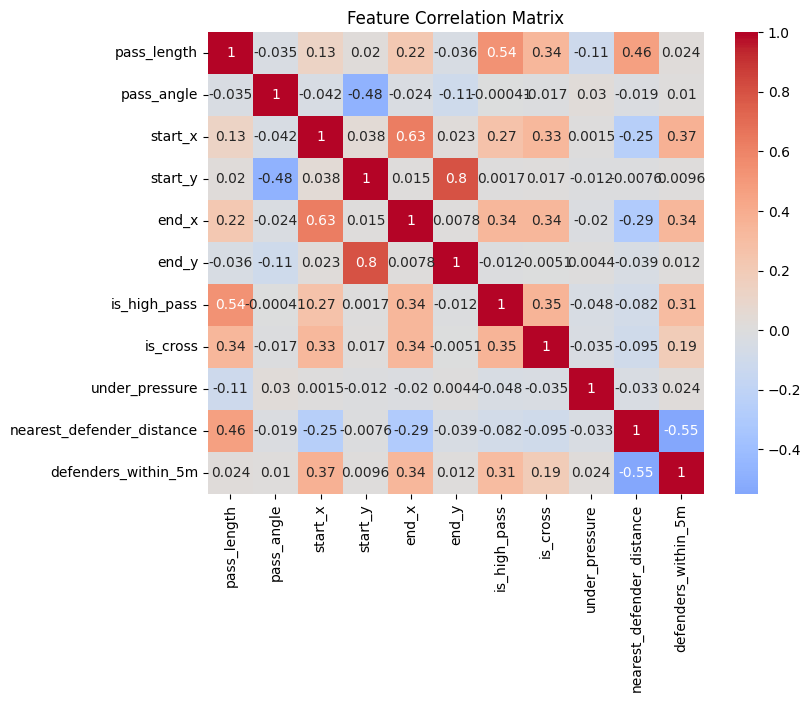

In [57]:
corr = passes_with_360[[
    'pass_length',
    'pass_angle',
    'start_x',
    'start_y',
    'end_x',
    'end_y',
    'is_high_pass',
    'is_cross',
    'under_pressure',
    'nearest_defender_distance',
    'defenders_within_5m'
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

#### Correlation Insight
It appears that only start_y and end_y have a concerning level of correlation, start_x and end_x are highly correlated as well. This makes sense because most passes are not going to be cross-field balls and so starting and finishing in a similar part of the pitch is expected. To reduce redundancy, I will keep the ending coordinates, and remove the starting coordinates as features, I feel that the end location of a pass is more relevant to whether a shot occurred than the starting location of the pass.

### Modelling
I will begin with a logistic regression model, as I want to predict a binary outcome (whether a pass leads to a shot). Logistic regression is, therefore, more appropriate than a linear model such as OLS.

Given the sample size (just under 6,000 observations) and relatively small number of features, logistic regression provides a good balance between model simplicity and explanatory power. It allows for clear interpretation of feature effects, which is important for generating actionable insights for coaching.

More complex models could potentially improve predictive performance, but may reduce interpretability if they operate as black-box models. Given the scope and timeframe of this task, I want to prioritise a transparent and explainable model, with a longer-term view of iteratively improving the model.

As a secondary step, a random forest model will be used to provide a comparison in predictive performance.

In [58]:
# Features
features = [
    'pass_length',
    'pass_angle',
    'end_x',
    'end_y',
    'is_high_pass',
    'is_cross',
    'under_pressure',
    'nearest_defender_distance',
    'defenders_within_5m'
]

X = passes_with_360[features]
y = passes_with_360['is_shot_assist']

In [59]:
# Converting boolean features to integers
X['under_pressure'] = X['under_pressure'].astype(int)
y = y.astype(int)

In [60]:
# Checking missing values
print(X.isna().mean())

pass_length                  0.0
pass_angle                   0.0
end_x                        0.0
end_y                        0.0
is_high_pass                 0.0
is_cross                     0.0
under_pressure               0.0
nearest_defender_distance    0.0
defenders_within_5m          0.0
dtype: float64


In [61]:
# Splitting train and test retaining 20% of data for testing

# I am using a stratified sample due to the low percentage of positive signals
# I want to ensure that a relatively even number of positive signals are present in both the train and test samples
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14, stratify=y
)

In [62]:
# Modelling with Logistic Regression
# Using maximum of 1000 iterations to give the model enough time to converge
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [63]:
# Inspecting coefficients
coefficients = pd.DataFrame(
    {'feature': features,
     'coefficient': model.coef_[0]
    }
)

coefficients = coefficients.sort_values(by='coefficient', ascending=False)
print(coefficients)

                     feature  coefficient
5                   is_cross     0.414331
2                      end_x     0.040958
0                pass_length     0.031546
3                      end_y    -0.002875
1                 pass_angle    -0.014988
4               is_high_pass    -0.064828
7  nearest_defender_distance    -0.076425
8        defenders_within_5m    -0.185117
6             under_pressure    -0.234293


In [64]:
# Checking output using a scaler to get better coefficient comparisons
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_train)

model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [65]:
# Inspecting coefficients
coefficients = pd.DataFrame(
    {'feature': features,
     'coefficient': model_scaled.coef_[0]
    }
)

coefficients = coefficients.sort_values(by='coefficient', ascending=False)
print(coefficients)

                     feature  coefficient
2                      end_x     0.529041
0                pass_length     0.296816
5                   is_cross     0.107264
4               is_high_pass    -0.018582
1                 pass_angle    -0.027518
3                      end_y    -0.062134
6             under_pressure    -0.085305
8        defenders_within_5m    -0.171385
7  nearest_defender_distance    -0.411905


In [66]:
# Model performance checks
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1069
           1       0.00      0.00      0.00        66

    accuracy                           0.94      1135
   macro avg       0.47      0.50      0.49      1135
weighted avg       0.89      0.94      0.91      1135



#### Model Performance Insight
The model achieves high overall accuracy but fails to identify shot-assist events. This is due to class imbalance, where the rarity of positive outcomes leads the model to favour predicting the majority class. As a result, evaluation focuses on coefficient interpretation rather than predictive performance.

### Model improvements
Off the back of the coefficients, it appears that longer passes are associated with shot-assists. This would track with slightly longer line-breaking passes potentially being into more dangerous areas to allow for shooting chances. However, my assumption would be that there should be diminishing returns where passes that are very long become less valuable in creating shooting chances.

To explore this, a quadratic term for pass length will be introduced to test for a potential non-linear relationship and identify whether an optimal pass length exists. As this introduces features on different scales, the data will be standardised prior to modelling.

The squared variable will increase correlation between features, but I consider this an acceptable trade-off for capturing potential non-linear effects.

In [67]:
# Create squared feature
passes_with_360['pass_length_sq'] = passes_with_360['pass_length'] ** 2

In [68]:
# Updated features
features = [
    'pass_length',
    'pass_length_sq',
    'pass_angle',
    'end_x',
    'end_y',
    'is_high_pass',
    'is_cross',
    'under_pressure',
    'nearest_defender_distance',
    'defenders_within_5m'
]
X = passes_with_360[features]
y = passes_with_360['is_shot_assist'].astype(int)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14, stratify=y
)

In [70]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [71]:
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [72]:
# Inspecting coefficients
coefficients = pd.DataFrame(
    {'feature': features,
     'coefficient': model_scaled.coef_[0]
    }
)

coefficients = coefficients.sort_values(by='coefficient', ascending=False)
print(coefficients)

                     feature  coefficient
3                      end_x     0.531315
0                pass_length     0.530462
6                   is_cross     0.101277
5               is_high_pass    -0.010059
2                 pass_angle    -0.027377
4                      end_y    -0.064690
7             under_pressure    -0.080490
9        defenders_within_5m    -0.157889
1             pass_length_sq    -0.241614
8  nearest_defender_distance    -0.395108


#### Coefficient Insight
The relationship between pass length and shot creation appears to be non-linear, with evidence of an optimal range rather than a strictly increasing effect.

In [73]:
# Model performance checks
X_test_scaled = scaler.transform(X_test)
y_pred = model_scaled.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1069
           1       0.00      0.00      0.00        66

    accuracy                           0.94      1135
   macro avg       0.47      0.50      0.49      1135
weighted avg       0.89      0.94      0.91      1135



#### Model Insight
Introducing a non-linear term improves the model’s ability to identify shot-assist events, increasing recall, but reduces overall accuracy due to the class imbalance.

#### Further improvements
I will add two further spatial features to improve interpretability: whether the pass ends in the box, or whether it ends in a central area.

In [74]:
# Defining is_central
passes_with_360['is_central'] = passes_with_360['end_y'].between(30, 50).astype(int)

In [75]:
# Defining into_box - StatsBomb pitch pentalty box begins at ~102 x coordinate and between ~18 and ~62 y coordinates
passes_with_360['into_box'] = (
    (passes_with_360['end_x'] >= 102) &
    (passes_with_360['end_y'].between(18, 62))
).astype(int)

In [76]:
features = [
    'pass_length',
    'pass_length_sq',
    'pass_angle',
    'end_x',
    'end_y',
    'is_high_pass',
    'is_cross',
    'is_central',
    'into_box',
    'under_pressure',
    'nearest_defender_distance',
    'defenders_within_5m'
]

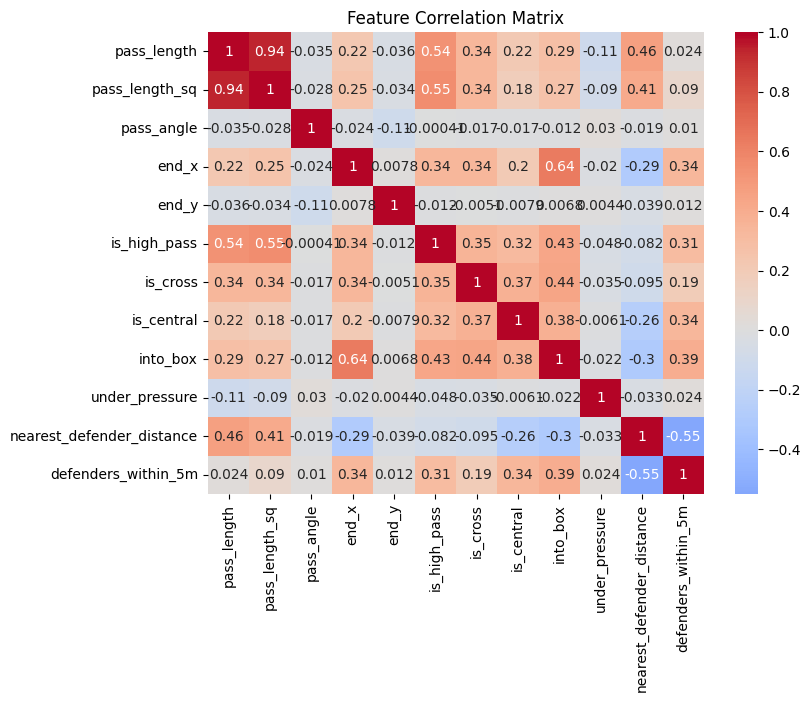

In [77]:
# Checking correlation of new features
corr = passes_with_360[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

#### Coefficient Output
As expected, pass_length and its squared term are highly correlated, as the quadratic feature is derived directly from the original variable. This is an intentional inclusion to capture potential non-linear effects, and the trade-off is considered acceptable. The remaining correlations are consistent with the design of the features, and are not of a magnitude that would negatively impact the model.

In [78]:
X = passes_with_360[features]
y = passes_with_360['is_shot_assist'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14, stratify=y
)

In [79]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [80]:
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [81]:
# Inspecting coefficients
coefficients = pd.DataFrame(
    {'feature': features,
     'coefficient': model_scaled.coef_[0]
    }
)

coefficients = coefficients.sort_values(by='coefficient', ascending=False)
print(coefficients)

                      feature  coefficient
7                  is_central     0.682024
8                    into_box     0.432373
3                       end_x     0.313405
1              pass_length_sq     0.108474
10  nearest_defender_distance     0.030100
2                  pass_angle    -0.024473
0                 pass_length    -0.045965
6                    is_cross    -0.065754
4                       end_y    -0.084535
5                is_high_pass    -0.091687
9              under_pressure    -0.126384
11        defenders_within_5m    -0.218981


In [82]:
# Model performance checks
X_test_scaled = scaler.transform(X_test)
y_pred = model_scaled.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1069
           1       0.00      0.00      0.00        66

    accuracy                           0.94      1135
   macro avg       0.47      0.50      0.49      1135
weighted avg       0.89      0.94      0.91      1135



### Model Redundancy Following Additional Spatial Features

The addition of is_central and into_box alongside the raw coordinate features introduces substantial overlap in how pass destination is represented. Rather than creating a completely unusable model, this mainly reduces interpretability, as multiple features are capturing similar aspects of the attacking location.

This is evident in the large positive coefficients on location-related features, suggesting that the model places great weight on overlapping representations of dangerous pass destinations. While the broad football story remains sensible, the feature effects become harder to distinguish cleanly.

To address this, the spatial representation will be simplified by removing the raw coordinate features and moving toward mutually exclusive higher-level spatial zones. This preserves the key location information while making the resulting coefficients easier to interpret.

In [83]:
features = [
    'pass_length',
    'pass_length_sq',
    'pass_angle',
    'is_central',
    'into_box',
    'is_high_pass',
    'is_cross',
    'under_pressure',
    'nearest_defender_distance',
    'defenders_within_5m'
]

In [84]:
y = passes_with_360['is_shot_assist'].astype(int)
X = passes_with_360[features]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14, stratify=y
)

In [85]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [86]:
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [87]:
# Inspecting coefficients
coefficients = pd.DataFrame(
    {'feature': features,
     'coefficient': model_scaled.coef_[0]
    }
)

coefficients = coefficients.sort_values(by='coefficient', ascending=False)
print(coefficients)

                     feature  coefficient
3                 is_central     0.641603
4                   into_box     0.600331
1             pass_length_sq     0.160030
8  nearest_defender_distance    -0.018399
2                 pass_angle    -0.019047
6                   is_cross    -0.050292
0                pass_length    -0.054773
5               is_high_pass    -0.087849
7             under_pressure    -0.121540
9        defenders_within_5m    -0.213004


In [88]:
# Model performance checks
X_test_scaled = scaler.transform(X_test)
y_pred = model_scaled.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1069
           1       0.00      0.00      0.00        66

    accuracy                           0.94      1135
   macro avg       0.47      0.50      0.49      1135
weighted avg       0.89      0.94      0.91      1135



### Model behaviour following feature simplification
Following the removal of the raw coordinate features, the model remains interpretable, but the inclusion of both is_central and into_box still creates some redundancy in how pass destination is represented. Both features capture related aspects of attacking location, so the model places substantial weight on them. The football story remains sensible, but the individual contribution of each spatial feature is harder to separate cleanly.

To address this, I will redefine the spatial features into mutually exclusive zones, separating passes into the box from central areas outside the box. This preserves the key location information while improving interpretability.

In [89]:
# Defining central_not_in_box
passes_with_360['central_not_in_box'] = (
    (passes_with_360['end_y'].between(30, 50)) &
    (passes_with_360['end_x'] < 102)
).astype(int)

In [90]:
# Checking that there's no overlap when there shouldn't be
(passes_with_360['into_box'] & passes_with_360['central_not_in_box']).sum()

np.int64(0)

In [91]:
# Updating features
features = [
    'pass_length',
    'pass_length_sq',
    'pass_angle',
    'into_box',
    'central_not_in_box',
    'is_high_pass',
    'is_cross',
    'under_pressure',
    'nearest_defender_distance',
    'defenders_within_5m'
]

In [92]:
y = passes_with_360['is_shot_assist'].astype(int)
X = passes_with_360[features]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=14, stratify=y
)

In [93]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [94]:
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [95]:
# Inspecting coefficients
coefficients = pd.DataFrame(
    {'feature': features,
     'coefficient': model_scaled.coef_[0]
    }
)

coefficients = coefficients.sort_values(by='coefficient', ascending=False)
print(coefficients)

                     feature  coefficient
3                   into_box     0.851985
4         central_not_in_box     0.536434
0                pass_length     0.189752
6                   is_cross     0.063837
1             pass_length_sq    -0.015919
2                 pass_angle    -0.016177
5               is_high_pass    -0.016880
7             under_pressure    -0.102735
9        defenders_within_5m    -0.154939
8  nearest_defender_distance    -0.163101


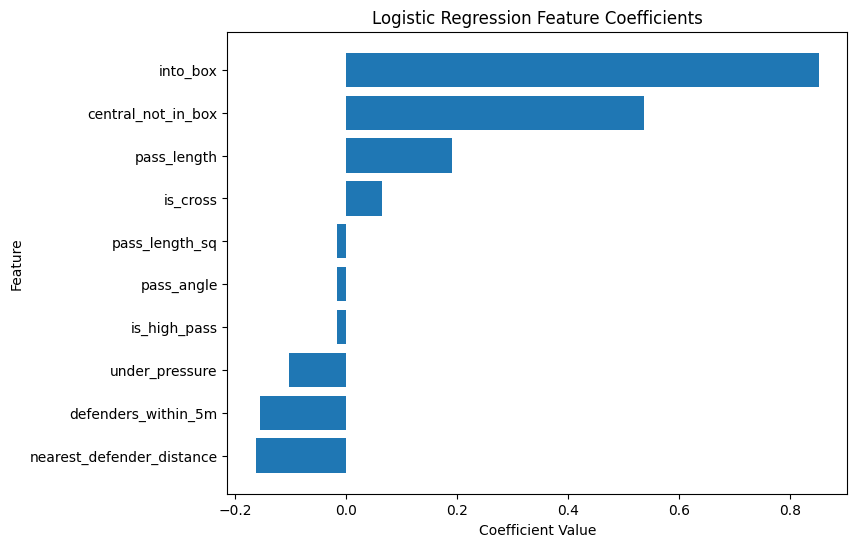

In [96]:
# Visualising Coefficients
coefficients_sorted = coefficients.sort_values(by='coefficient')

plt.figure(figsize=(8,6))
plt.barh(coefficients_sorted['feature'], coefficients_sorted['coefficient'])
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

### Coefficient Bar Chart
The coefficient plot provides a clear view of which features are associated with an increased or decreased likelihood of a pass leading directly to a shot. Spatial destination features are the strongest positive drivers, while defensive pressure and local congestion act in the opposite direction. This suggests that where the pass goes, and the defensive context of the situation it enters, matter more than the exact mechanics of delivery.

In [97]:
# Model performance checks
X_test_scaled = scaler.transform(X_test)
y_pred = model_scaled.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1069
           1       0.00      0.00      0.00        66

    accuracy                           0.94      1135
   macro avg       0.47      0.50      0.49      1135
weighted avg       0.89      0.94      0.91      1135



#### Model Performance
Due to class imbalance, the model does not identify shot-assist events well at the default classification threshold. As a result, the focus is placed on interpreting the direction and relative importance of feature effects rather than predictive accuracy.

#### Model Comparison
I intend to use the above output from the logistic regression as the model output. However, it would be valuable to compare the coefficients against another model to test robustness and ensure there's consistency between models - even if just for a sanity check. If the RandomForest performs far better then we can rethink whether to use those outputs over the logistic regression, but I don't intend to spend too long tuning the hyperparameters of the RandomForest unless it becomes valuable.

In [98]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

importances = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importances)

                     feature  importance
2                 pass_angle    0.228544
8  nearest_defender_distance    0.220156
1             pass_length_sq    0.215381
0                pass_length    0.211360
3                   into_box    0.036888
9        defenders_within_5m    0.034214
6                   is_cross    0.017044
5               is_high_pass    0.013066
7             under_pressure    0.012005
4         central_not_in_box    0.011342


### Model Robustness
The final logistic regression model was re-fitted across multiple stratified train/test splits to assess whether the main coefficient estimates were stable across different partitions of the data.

In [99]:
features = [
    'pass_length',
    'pass_length_sq',
    'pass_angle',
    'into_box',
    'central_not_in_box',
    'under_pressure',
    'nearest_defender_distance',
    'defenders_within_5m',
    'is_high_pass',
    'is_cross'
]

results = []

for seed in [1, 14, 21, 42, 87]:
    X = passes_with_360[features].copy()
    y = passes_with_360['is_shot_assist'].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)

    results.append(model.coef_[0])

coef_stability = pd.DataFrame(results, columns=features)
coef_stability.describe().T[['mean', 'std']]

,mean,std
pass_length,0.264621,0.043448
pass_length_sq,0.008784,0.025988
pass_angle,0.025561,0.038682
into_box,0.871000,0.037818
central_not_in_box,0.541163,0.046668
under_pressure,-0.112984,0.047772
nearest_defender_distance,-0.278558,0.078299
defenders_within_5m,-0.211175,0.052930
is_high_pass,-0.070872,0.042389
is_cross,0.017474,0.034606


### Model Validation
The following section quantifies how much to trust the model's outputs.

Given the brief's emphasis on interpretability over predictive power, validation focuses on three things: ranking ability (AUC-ROC), lift over random selection (Average Precision), and calibration of predicted probabilities.

AUC-ROC is the primary metric here given class imbalance (5.8% positive rate). It measures whether the model correctly ranks a shot-creating pass above a non-shot-creating pass, independently of prediction threshold, and is not inflated by a model that simply predicts the majority class.

Baseline shot-assist rate: 0.058 (5.8%)
AUC-ROC:  0.765 ± 0.042
Avg Precision: 0.167 ± 0.031
AP lift over baseline: 2.9x


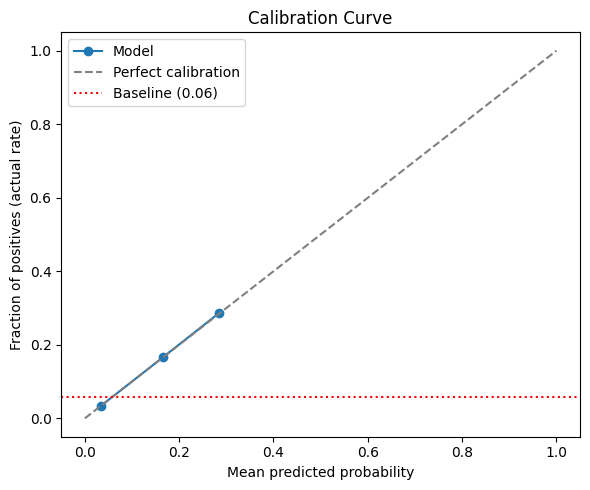

In [100]:
features = [
    'pass_length',
    'pass_length_sq',
    'pass_angle',
    'into_box',
    'central_not_in_box',
    'is_high_pass',
    'is_cross',
    'under_pressure',
    'nearest_defender_distance',
    'defenders_within_5m'
]
y = passes_with_360['is_shot_assist'].astype(int)
X = passes_with_360[features]

# Baseline
baseline = y.mean()
print(f"Baseline shot-assist rate: {baseline:.3f} ({baseline:.1%})")

# AUC-ROC and AP across CV splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=14)
auc_scores = []
ap_scores = []

for train, test in cv.split(X, y):
    X_train, X_test = X.iloc[train], X.iloc[test]
    y_train, y_test = y.iloc[train], y.iloc[test]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model.fit(X_train_scaled, y_train)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    auc_scores.append(roc_auc_score(y_test, y_prob))
    ap_scores.append(average_precision_score(y_test, y_prob))

print(f"AUC-ROC:  {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"Avg Precision: {np.mean(ap_scores):.3f} ± {np.std(ap_scores):.3f}")
print(f"AP lift over baseline: {np.mean(ap_scores)/baseline:.1f}x")

# Calibration plot
# Refitting on full data to get probabilities for calibration check
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)
model.fit(X_scaled, y)
y_prob_full = model.predict_proba(X_scaled)[:, 1]

fraction_pos, mean_pred = calibration_curve(y, y_prob_full, n_bins=8)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_pred, fraction_pos, marker='o', label='Model')
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
ax.axhline(baseline, linestyle=':', color='red', label=f'Baseline ({baseline:.2f})')
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (actual rate)")
ax.set_title("Calibration Curve")
ax.legend()
plt.tight_layout()
plt.show()

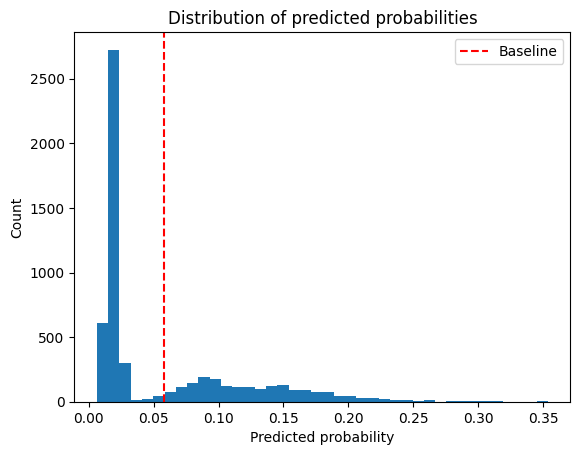

Passes predicted above baseline rate: 34.7%
Max predicted probability: 0.354


In [101]:
# Checking distribution of predicted probabilities
plt.hist(y_prob_full, bins=40)
plt.axvline(baseline, color='red', linestyle='--', label='Baseline')
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Distribution of predicted probabilities")
plt.legend()
plt.show()

print(f"Passes predicted above baseline rate: {(y_prob_full > baseline).mean():.1%}")
print(f"Max predicted probability: {y_prob_full.max():.3f}")

## Validation Summary

**Baseline:** 5.8% of final-third passes in this dataset lead directly to a shot.

**AUC-ROC: 0.765 ± 0.042:** across 5 stratified folds. The model correctly ranks a shot-creating pass above a non-shot-creating pass approximately 77% of the time. The stability across folds (±0.042) suggests the findings are not driven by a single lucky split.

**Average Precision: 0.167 ± 0.031:** a 2.9x lift over the baseline rate. Among passes the model scores highly, shot assists occur at nearly three times the background rate.

**Calibration:** Predicted probabilities are compressed into the 0–0.35 range, reflecting class imbalance. Within that range the calibration curve tracks reasonably, but absolute probability values should not be read literally. The model is suited to ranking and comparing scenarios, not to assigning precise likelihoods to individual passes.

**Probability distribution:** 34.7% of passes are scored above the baseline rate, with a meaningful tail extending to 0.352. The model is not simply predicting near-zero for everything — it is genuinely discriminating between passes, with the highest scores concentrated in box entries and central zones as expected from the coefficients.

**Overall trust level:** Moderate-to-good confidence in the model's directional findings, particularly the dominance of pass destination. Lower confidence in event-level predictions for individual passes. These results support using the model as a tactical pattern tool rather than a pass-by-pass classifier.

### Model with interaction features

A purely additive model assumes that the value of entering the box is constant regardless of defensive context or delivery type. In practice, these effects are likely conditional.

I wanted to test a small set of interaction terms to assess whether the value of entering dangerous areas depends on pressure, congestion, and delivery style.

#### Engineering features:
I already engineered an example of an interaction feature with pass_length_sq.

I made features that combined into_box and central_not_in_box with defenders_within_5m. To understand the impact of passes that enter the box or central areas when the receiver is under immediate crowded pressure.

is_cross and into_box measures the effectiveness of crosses into the box, with a similar interaction created for is_high_pass.

pass_length combined with into_box measures the effect of passing distance specifically into the box and how well that creates dangerous shooting chances.

In [102]:
# Interaction features
passes_with_360["into_box_x_congestion"] = (
    passes_with_360["into_box"] * passes_with_360["defenders_within_5m"]
)

passes_with_360["central_x_congestion"] = (
    passes_with_360["central_not_in_box"] * passes_with_360["defenders_within_5m"]
)

passes_with_360["cross_x_into_box"] = (
    passes_with_360["is_cross"] * passes_with_360["into_box"]
)

passes_with_360["high_pass_x_into_box"] = (
    passes_with_360["is_high_pass"] * passes_with_360["into_box"]
)

passes_with_360["pass_length_x_into_box"] = (
    passes_with_360["pass_length"] * passes_with_360["into_box"]
)

In [103]:
base_features = [
    "pass_length",
    "pass_length_sq",
    "pass_angle",
    "into_box",
    "central_not_in_box",
    "is_high_pass",
    "is_cross",
    "under_pressure",
    "nearest_defender_distance",
    "defenders_within_5m",
]

interaction_features = [
    "into_box_x_congestion",
    "central_x_congestion",
    "cross_x_into_box",
    "high_pass_x_into_box",
    "pass_length_x_into_box",
]

features_with_interactions = base_features + interaction_features

#### Comparing the base model to a model with the interaction features

In [104]:
y = passes_with_360["is_shot_assist"].astype(int)

X_base = passes_with_360[base_features]
X_inter = passes_with_360[features_with_interactions]

baseline = y.mean()
print(f"Baseline shot-assist rate: {baseline:.3f} ({baseline:.1%})")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=14)

def evaluate_model(X, y, label):
    auc_scores = []
    ap_scores = []
    all_coefs = []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=14
            ))
        ])

        pipe.fit(X_train, y_train)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        auc_scores.append(roc_auc_score(y_test, y_prob))
        ap_scores.append(average_precision_score(y_test, y_prob))
        all_coefs.append(pipe.named_steps["model"].coef_[0])

    coef_df = pd.DataFrame(all_coefs, columns=X.columns)

    stability_df = pd.DataFrame({
        "feature": X.columns,
        "mean_coef": coef_df.mean(axis=0).values,
        "std_coef": coef_df.std(axis=0).values,
        "abs_mean_coef": np.abs(coef_df.mean(axis=0).values),
        "sign_consistency": [
            np.mean(np.sign(coef_df[col]) == np.sign(coef_df[col].mean()))
            for col in coef_df.columns
        ]
    }).sort_values("abs_mean_coef", ascending=False)

    print(f"\n{label}")
    print(f"AUC-ROC:       {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
    print(f"Avg Precision: {np.mean(ap_scores):.3f} ± {np.std(ap_scores):.3f}")
    print(f"AP lift:       {np.mean(ap_scores)/baseline:.2f}x baseline")

    return {
        "auc_scores": auc_scores,
        "ap_scores": ap_scores,
        "coef_df": coef_df,
        "stability_df": stability_df
    }

base_results = evaluate_model(X_base, y, "Additive logistic regression")
inter_results = evaluate_model(X_inter, y, "Interaction logistic regression")

Baseline shot-assist rate: 0.058 (5.8%)

Additive logistic regression
AUC-ROC:       0.767 ± 0.042
Avg Precision: 0.164 ± 0.034
AP lift:       2.84x baseline

Interaction logistic regression
AUC-ROC:       0.760 ± 0.041
Avg Precision: 0.167 ± 0.034
AP lift:       2.89x baseline


In [105]:
# View additive model results
base_results["stability_df"].round(3)

,feature,mean_coef,std_coef,abs_mean_coef,sign_consistency
3,into_box,0.888,0.048,0.888,1.0
4,central_not_in_box,0.523,0.062,0.523,1.0
0,pass_length,0.489,0.089,0.489,1.0
8,nearest_defender_distance,-0.334,0.074,0.334,1.0
9,defenders_within_5m,-0.232,0.026,0.232,1.0
1,pass_length_sq,-0.156,0.058,0.156,1.0
5,is_high_pass,-0.136,0.034,0.136,1.0
7,under_pressure,-0.072,0.048,0.072,1.0
6,is_cross,0.015,0.034,0.015,0.8
2,pass_angle,-0.000,0.032,0.000,0.6


In [106]:
# View interaction model results
inter_results["stability_df"].round(3)

,feature,mean_coef,std_coef,abs_mean_coef,sign_consistency
3,into_box,0.975,0.060,0.975,1.0
0,pass_length,0.540,0.123,0.540,1.0
4,central_not_in_box,0.527,0.079,0.527,1.0
8,nearest_defender_distance,-0.377,0.069,0.377,1.0
9,defenders_within_5m,-0.313,0.243,0.313,1.0
5,is_high_pass,-0.229,0.062,0.229,1.0
14,pass_length_x_into_box,-0.191,0.117,0.191,1.0
13,high_pass_x_into_box,0.135,0.034,0.135,1.0
1,pass_length_sq,-0.117,0.039,0.117,1.0
6,is_cross,0.075,0.087,0.075,0.8


In [107]:
# Fit additive model on all data
final_base_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=14
    ))
])

final_base_pipe.fit(X_base, y)

final_base_coefs = pd.DataFrame({
    "feature": X_base.columns,
    "final_coef": final_base_pipe.named_steps["model"].coef_[0]
}).sort_values("final_coef", key=np.abs, ascending=False)

final_base_coefs.round(3)

,feature,final_coef
3,into_box,0.887
4,central_not_in_box,0.523
0,pass_length,0.490
8,nearest_defender_distance,-0.329
9,defenders_within_5m,-0.231
1,pass_length_sq,-0.158
5,is_high_pass,-0.135
7,under_pressure,-0.071
6,is_cross,0.015
2,pass_angle,-0.001


In [108]:
# Fit interaction model on all data
final_inter_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=14
    ))
])

final_inter_pipe.fit(X_inter, y)

final_inter_coefs = pd.DataFrame({
    "feature": X_inter.columns,
    "final_coef": final_inter_pipe.named_steps["model"].coef_[0]
}).sort_values("final_coef", key=np.abs, ascending=False)

final_inter_coefs.round(3)

,feature,final_coef
3,into_box,0.979
0,pass_length,0.542
4,central_not_in_box,0.526
8,nearest_defender_distance,-0.372
9,defenders_within_5m,-0.286
5,is_high_pass,-0.224
14,pass_length_x_into_box,-0.201
13,high_pass_x_into_box,0.132
1,pass_length_sq,-0.115
6,is_cross,0.071


## Testing conditional effects with interaction terms

The additive logistic regression model assumes that each feature contributes independently to shot creation. In practice, this is a strong assumption. The value of a pass into the box may depend on factors such as defensive pressure, congestion around the receiver, or the type of delivery.

To test this, I introduced a small set of interaction terms designed to capture whether the effect of entering dangerous areas is conditional on defensive context and pass execution.

The interaction model produced only a marginal improvement in average precision and no meaningful change in AUC-ROC. The lack of performance gain suggests that the effect of pass destination is largely consistent across contexts, reinforcing its role as the dominant and most reliable tactical driver.

In addition, several interaction terms were small in magnitude or did not consistently align with clear football interpretation, particularly those related to congestion. This reduces confidence in their reliability given the limited sample size.

Based on this, I will retain the simpler additive model as the primary model. It captures the core relationships in a more stable and interpretable way, while the interaction model serves as a useful robustness check rather than a foundation for the final recommendations.

# Model Output and Interpretation
The results of the final model suggest that the destination of a pass, and the defensive context of where it ends, are the primary drivers of whether it leads to a shot.

Passes played into the penalty box have the strongest positive association with shot creation, with passes into central areas outside the box also contributing positively, but to a lesser extent. This indicates a clear hierarchy of attacking value, where central and advanced areas are significantly more effective than wider or deeper zones.

Defensive context features also appear in the model, though their interpretation requires care. The raw data shows that shot assist rate actually increases with defender density, suggesting these features partly capture pass destination, congested areas tend to be central and advanced zones where shots naturally occur. Once location is controlled for in the model, the congestion features act negatively, which may reflect that within any given zone, a heavily surrounded receiver is less likely to create a shot directly. The defensive context features should therefore be interpreted as secondary to pass destination rather than as independent drivers.

Pass characteristics such as length and direction appear to play a secondary role once pass destination is accounted for. There is limited evidence of a non-linear relationship between pass length and shot creation, indicating that how the ball is delivered is less important than where it is delivered.

Additional features relating to pass type, such as pass height, suggest that different delivery mechanisms may influence effectiveness, although these effects are less pronounced than spatial factors.

### Pass Length Interpretation
Earlier model iterations suggested a possible non-linear relationship between pass length and direct shot creation. However, once pass destination was represented more clearly through mutually exclusive spatial zones, the non-linear effect became much weaker.

This suggests that pass length plays a secondary role relative to destination. In other words, the value of the pass is driven less by how far it travels, and more by where it ends and the defensive context it enters.

## Recommendations
The model suggests that the most effective final-third passes are those that enter the penalty box, or central areas just outside it. Pass destination is the dominant driver of direct shot creation. How the pass is delivered, and the defensive context it enters, appear secondary once location is accounted for, but still provides some analytical nuance.

From a coaching perspective, this supports attacking patterns that prioritise pass destination over pass mechanics. Specifically, this could mean creating routes into the box and central zones before the defensive shape is set. In practice, this would mean prioritising:
- Box entries and central entries played before the defence is fully set
- Passing combinations that access central areas without forcing the receiver into heavy local traffic
- Attacking structures that avoid circulating into wide areas and then delivering into heavily populated zones

In match review, I would focus specifically on possessions where the final pass entered the box or central zone and assess whether the attacking pattern created a clear route into those areas or relied on individual quality to force the pass through.

## Key Assumption and How It Affects the Recommendation
A key assumption in this analysis is that direct shot assists are a suitable proxy for chance creation. This creates a clear and interpretable target, but it excludes situations where a pass creates a strong shooting opportunity after one or more additional actions, such as a controlling touch or short carry.

If this assumption does not hold, then the recommendation would need to shift slightly. Rather than focusing only on the final pass into dangerous areas, the analysis would need to place more weight on short attacking sequences that move the ball into the box or central zones before the shot occurs.

Similarly, the model suggests that the position of the end of the pass is the main driver of the model. If this explanation is wrong and defender density genuinely does drive shot creation (although this feels unlikely in a real-world application), the recommendation would shift toward exploiting defensive disorganisation rather than simply targeting box entries.

In practical terms, the current recommendation is best interpreted as guidance on direct chance creation. If a club wanted to study broader attacking value, the next step would be to redefine the target around short possession sequences leading to shots, rather than the final pass alone.

## Random Forest Comparison
A Random Forest model was fitted as a non-linear comparison to test whether the broad feature story remained consistent outside of the logistic regression framework.

The resulting feature importance rankings differ from the logistic regression coefficients, with continuous variables such as pass angle and pass length appearing more prominent. This is expected, as tree-based models tend to favour variables with many possible split points, while binary zone indicators are less favoured in standard feature-importance measures.

For this reason, the logistic regression remains the preferred model for interpretation. However, the Random Forest still provides useful supporting evidence that pass characteristics and defensive context contribute to differentiating between attacking situations once spatial destination is taken into account.

## Limitations
This analysis is limited to one team and one season, and is focused on direct shot creation rather than broader attacking sequence value. In addition, the use of shot assists excludes passes followed by a controlling touch or short carry before the shot, and the 360 data provides only partial spatial context at the moment the pass is played.

The quality of the shot that the pass created is also not taken into account.

I decided not to utilise the SkillCorner open repository mainly due to the small sample size. However, the fact that the data was for the Australian A-League was also a blocker, as comparing different teams, leagues, and matches is difficult and would not provide analytically robust insights, especially with such a small sample.

Calibration is assessed on the full training set rather than a held-out set (due to data availability), so the calibration curve likely overstates how well-calibrated the model is on unseen data. The cross-validated AUC and AP scores are the more reliable indicators of out-of-sample performance.

### Model Trust and Validity
The final logistic regression model should be trusted primarily as an interpretive model rather than a predictive one. Due to class imbalance, it does not perform well as a direct event-level classifier at the default threshold. However, it remains useful for understanding the direction and relative importance of the main drivers of direct shot creation.

To test the robustness of the coefficient estimates, the final model was re-fitted across multiple stratified train/test splits. The main feature effects remained stable across these runs. In particular, passes into the box and passes into central areas outside the box consistently showed strong positive relationships with shot creation, while local defensive congestion and pressure-related features remained negative. The weaker and less stable coefficients on features such as pass angle, pass length squared, and cross type further support the conclusion that pass destination and defensive context are the dominant signals in the model.

This increases confidence that the core findings are not being driven by a single random partition of the data, which was shown when validating the model with the AUC-ROC of 0.765 ± 0.042. As a result, the model is considered sufficiently trustworthy for tactical interpretation, while still being too limited for precise event-level prediction, in its current form. This means the model is best used to inform tactical understanding of favourable passing situations, rather than to assign high-confidence probabilities to individual passes.

## Conclusion
The strongest conclusion from this analysis is that direct chance creation is driven primarily by where the pass ends. For a football club, the actionable takeaway is to prioritise attacking patterns that generate box entries and central entries, with pass destination being the dominant factor over delivery mechanics or defensive context.

## Future Improvements
Further improvements could include incorporating additional contextual features, such as player movement and pass reception dynamics, to better distinguish between passes played into space and those received under control.

Additionally, extending the analysis across multiple teams and competitions would help assess whether these findings generalise beyond a single team context. As well as giving a clear definition for passes that lead to a shot, to allow a wider sample with passes that have potentially 1 or 2 touches between the pass and shot.

The most valuable improvement would be to move away from looking at whether a pass is likely to turn into a shot, but how good the shot was. If I had a bigger sample, I would've liked to utilise the xG of the shot to understand which passes create the *best* shooting opportunities, as opposed to just whether they create *a* shooting opportunity.

A potential next step would be to develop a lightweight interactive tool that allows users to simulate passes across different areas of the pitch and observe the predicted likelihood of shot creation.

I have created a basic version of what the above idea could be, and deployed it using Streamlit Cloud. It can be found at this link: https://dcfc-data-scientist-task-qyde5acdq2euwjb75we3fy.streamlit.app/